# CO4 – Assessment Tool 1: Coding Challenge
**Course:** Machine Learning (ITA 06)
**Course Outcome:** CO4 – K-Nearest Neighbour Learning, Locally Weighted Regression, Radial Basis Functions, Case-Based Learning

This notebook contains solutions to all three questions of the Coding Challenge:
1. Naïve Bayes Classifier (with and without Laplace smoothing)
2. Genetic Algorithm for function optimization
3. Support Vector Machine (SVM) for binary classification


---
## Question 1: Naïve Bayes Classifier

**Task:** Implement a Naïve Bayes classifier for a given dataset. Compute prior and conditional
probabilities, classify a test instance, display predicted class labels, evaluate accuracy, and
compare results with and without Laplace smoothing.

### Approach
We build a Naïve Bayes classifier **from first principles** (no `sklearn`) on a small categorical
"Play Tennis" style dataset (Outlook, Temperature, Humidity, Wind → PlayTennis), so that the prior
and conditional probability computations are fully visible. We then evaluate accuracy on a held-out
test split, with and without Laplace (add-one) smoothing.


In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict

# ----- Dataset -----
data = {
    'Outlook':     ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast',
                     'Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool',
                     'Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':    ['High','High','High','High','Normal','Normal','Normal',
                     'High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':        ['Weak','Strong','Weak','Weak','Weak','Strong','Strong',
                     'Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis':  ['No','No','Yes','Yes','Yes','No','Yes',
                     'No','Yes','Yes','Yes','Yes','Yes','No']
}
df = pd.DataFrame(data)
df


,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [2]:
# ----- Train / test split (simple manual split) -----
train_df = df.iloc[:11].reset_index(drop=True)
test_df  = df.iloc[11:].reset_index(drop=True)
features = ['Outlook', 'Temperature', 'Humidity', 'Wind']
target = 'PlayTennis'

print("Train size:", len(train_df), " Test size:", len(test_df))
train_df


Train size: 11  Test size: 3


,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [3]:
class NaiveBayesClassifier:
    def __init__(self, laplace=True):
        self.laplace = laplace
        self.classes = None
        self.priors = {}
        self.likelihoods = {}   # likelihoods[feature][value][class] = P(value|class)
        self.feature_values = {}

    def fit(self, X: pd.DataFrame, y: pd.Series):
        self.classes = y.unique()
        n = len(y)

        # ---- Prior probabilities P(class) ----
        for c in self.classes:
            self.priors[c] = np.sum(y == c) / n

        # ---- Conditional probabilities P(feature=value | class) ----
        self.feature_values = {f: X[f].unique() for f in X.columns}
        for f in X.columns:
            self.likelihoods[f] = {}
            n_values = len(self.feature_values[f])
            for v in self.feature_values[f]:
                self.likelihoods[f][v] = {}
                for c in self.classes:
                    class_subset = X[y == c]
                    count_v_c = np.sum(class_subset[f] == v)
                    count_c = np.sum(y == c)
                    if self.laplace:
                        prob = (count_v_c + 1) / (count_c + n_values)
                    else:
                        # add a tiny epsilon only to avoid hard zero crashing the product
                        prob = count_v_c / count_c if count_c > 0 else 0
                        if prob == 0:
                            prob = 1e-9   # floor, NOT proper smoothing
                    self.likelihoods[f][v][c] = prob
        return self

    def predict_proba(self, x: pd.Series):
        scores = {}
        for c in self.classes:
            score = self.priors[c]
            for f in x.index:
                v = x[f]
                score *= self.likelihoods[f].get(v, {}).get(c, 1e-9)
            scores[c] = score
        total = sum(scores.values())
        return {c: (s / total if total > 0 else 0) for c, s in scores.items()}

    def predict(self, X: pd.DataFrame):
        preds = []
        for _, row in X.iterrows():
            proba = self.predict_proba(row)
            preds.append(max(proba, key=proba.get))
        return preds


def accuracy(y_true, y_pred):
    y_true = list(y_true)
    correct = sum(1 for t, p in zip(y_true, y_pred) if t == p)
    return correct / len(y_true)


In [4]:
# ----- Train WITH Laplace smoothing -----
nb_smoothed = NaiveBayesClassifier(laplace=True)
nb_smoothed.fit(train_df[features], train_df[target])

print("Priors P(class):", nb_smoothed.priors)
print()
print("Sample conditional prob P(Outlook=Sunny | class):", nb_smoothed.likelihoods['Outlook']['Sunny'])


Priors P(class): {'No': np.float64(0.36363636363636365), 'Yes': np.float64(0.6363636363636364)}

Sample conditional prob P(Outlook=Sunny | class): {'No': np.float64(0.5714285714285714), 'Yes': np.float64(0.3)}


In [5]:
# ----- Classify test instances (WITH smoothing) -----
preds_smoothed = nb_smoothed.predict(test_df[features])
test_df_result = test_df.copy()
test_df_result['Predicted (Laplace)'] = preds_smoothed
print(test_df_result)

acc_smoothed = accuracy(test_df[target], preds_smoothed)
print(f"\nAccuracy WITH Laplace smoothing: {acc_smoothed*100:.2f}%")


    Outlook Temperature Humidity    Wind PlayTennis Predicted (Laplace)
0  Overcast        Mild     High  Strong        Yes                 Yes
1  Overcast         Hot   Normal    Weak        Yes                 Yes
2      Rain        Mild     High  Strong         No                 Yes

Accuracy WITH Laplace smoothing: 66.67%


In [6]:
# ----- Train and classify WITHOUT Laplace smoothing -----
nb_raw = NaiveBayesClassifier(laplace=False)
nb_raw.fit(train_df[features], train_df[target])
preds_raw = nb_raw.predict(test_df[features])

test_df_result['Predicted (No Smoothing)'] = preds_raw
print(test_df_result)

acc_raw = accuracy(test_df[target], preds_raw)
print(f"\nAccuracy WITHOUT Laplace smoothing: {acc_raw*100:.2f}%")


    Outlook Temperature Humidity    Wind PlayTennis Predicted (Laplace)  \
0  Overcast        Mild     High  Strong        Yes                 Yes   
1  Overcast         Hot   Normal    Weak        Yes                 Yes   
2      Rain        Mild     High  Strong         No                 Yes   

  Predicted (No Smoothing)  
0                      Yes  
1                      Yes  
2                      Yes  

Accuracy WITHOUT Laplace smoothing: 66.67%


In [7]:
# ----- Single new test instance -----
new_instance = pd.Series({'Outlook':'Sunny','Temperature':'Cool','Humidity':'High','Wind':'Strong'})
proba = nb_smoothed.predict_proba(new_instance)
print("New instance:", new_instance.to_dict())
print("Class probabilities (Laplace):", proba)
print("Predicted class:", max(proba, key=proba.get))


New instance: {'Outlook': 'Sunny', 'Temperature': 'Cool', 'Humidity': 'High', 'Wind': 'Strong'}
Class probabilities (Laplace): {'No': np.float64(0.6999125109361329), 'Yes': np.float64(0.300087489063867)}
Predicted class: No


### Analysis: Impact of Laplace Smoothing

| Aspect | Without Smoothing | With Laplace Smoothing |
|---|---|---|
| Zero-frequency values | Any feature value unseen in training for a class gets probability 0 (or an artificial floor), which can zero out or destabilize the whole posterior | Unseen combinations get a small non-zero probability, so the class score never collapses to exactly 0 |
| Robustness | Poor — a single unseen attribute value can wrongly eliminate the correct class | Good — probabilities remain well-behaved even with sparse training data |
| Bias | Unbiased when data is abundant | Slight bias toward uniformity, more noticeable with small datasets |
| Accuracy on small/sparse datasets | Tends to be lower and unstable | Tends to be equal or higher and more stable |

**Conclusion:** Laplace (add-one) smoothing is essential for small or sparse categorical datasets
such as this one, since raw relative-frequency estimates frequently contain zero counts. Smoothing
trades a small amount of bias for a large reduction in variance, generally improving generalization
and preventing the classifier from being overconfident about unseen feature combinations.


---
## Question 2: Genetic Algorithm for Function Optimization

**Task:** Implement a simple Genetic Algorithm (GA) to optimize a mathematical function. Initialize
a population, perform selection, crossover and mutation, evolve solutions over generations, display
fitness values and the best solution, and analyze how parameters influence convergence.

### Objective function
We maximize:  f(x) = x · sin(10πx) + 1.0,  for x ∈ [-1, 2]

This is a classic multi-modal benchmark function with several local maxima, which makes it a good
test of a GA's ability to avoid getting trapped in local optima.


In [8]:
import numpy as np
import random

random.seed(42)
np.random.seed(42)

# ----- Objective function to MAXIMIZE -----
def fitness_function(x):
    return x * np.sin(10 * np.pi * x) + 1.0

BOUNDS = (-1.0, 2.0)

def init_population(pop_size):
    return [random.uniform(*BOUNDS) for _ in range(pop_size)]

def evaluate(population):
    return [fitness_function(ind) for ind in population]

def select_parents(population, fitnesses, k=3):
    # Tournament selection
    selected = []
    for _ in range(len(population)):
        aspirants_idx = random.sample(range(len(population)), k)
        best_idx = max(aspirants_idx, key=lambda i: fitnesses[i])
        selected.append(population[best_idx])
    return selected

def crossover(parent1, parent2, rate=0.8):
    if random.random() < rate:
        alpha = random.random()
        child1 = alpha * parent1 + (1 - alpha) * parent2
        child2 = alpha * parent2 + (1 - alpha) * parent1
        return child1, child2
    return parent1, parent2

def mutate(individual, rate=0.1, sigma=0.15):
    if random.random() < rate:
        individual += random.gauss(0, sigma)
        individual = min(max(individual, BOUNDS[0]), BOUNDS[1])
    return individual


In [9]:
def genetic_algorithm(pop_size=30, generations=50, cx_rate=0.8, mut_rate=0.1, elitism=2, verbose=True):
    population = init_population(pop_size)
    history = []

    for gen in range(generations):
        fitnesses = evaluate(population)

        # Track best of this generation
        best_idx = int(np.argmax(fitnesses))
        best_x, best_f = population[best_idx], fitnesses[best_idx]
        history.append((gen, best_x, best_f, float(np.mean(fitnesses))))

        if verbose and gen % 10 == 0:
            print(f"Gen {gen:3d} | Best x = {best_x:8.4f} | Best f(x) = {best_f:8.4f} | Avg f(x) = {np.mean(fitnesses):8.4f}")

        # ----- Elitism: carry forward the best individuals -----
        elite_idx = np.argsort(fitnesses)[-elitism:]
        elites = [population[i] for i in elite_idx]

        # ----- Selection -----
        parents = select_parents(population, fitnesses)

        # ----- Crossover -----
        children = []
        for i in range(0, len(parents) - 1, 2):
            c1, c2 = crossover(parents[i], parents[i + 1], cx_rate)
            children.extend([c1, c2])
        while len(children) < pop_size:
            children.append(random.uniform(*BOUNDS))

        # ----- Mutation -----
        children = [mutate(c, mut_rate) for c in children]

        # ----- Replace population, keeping elites -----
        children[:elitism] = elites
        population = children

    final_fitnesses = evaluate(population)
    best_idx = int(np.argmax(final_fitnesses))
    return population[best_idx], final_fitnesses[best_idx], history

best_x, best_f, history = genetic_algorithm()
print(f"\nBest solution found: x = {best_x:.5f},  f(x) = {best_f:.5f}")


Gen   0 | Best x =   1.8716 | Best f(x) =   2.4556 | Avg f(x) =   0.9383
Gen  10 | Best x =   1.8505 | Best f(x) =   2.8503 | Avg f(x) =   2.7459
Gen  20 | Best x =   1.8505 | Best f(x) =   2.8503 | Avg f(x) =   2.7268
Gen  30 | Best x =   1.8505 | Best f(x) =   2.8503 | Avg f(x) =   2.7165
Gen  40 | Best x =   1.8505 | Best f(x) =   2.8503 | Avg f(x) =   2.7886

Best solution found: x = 1.85055,  f(x) = 2.85027


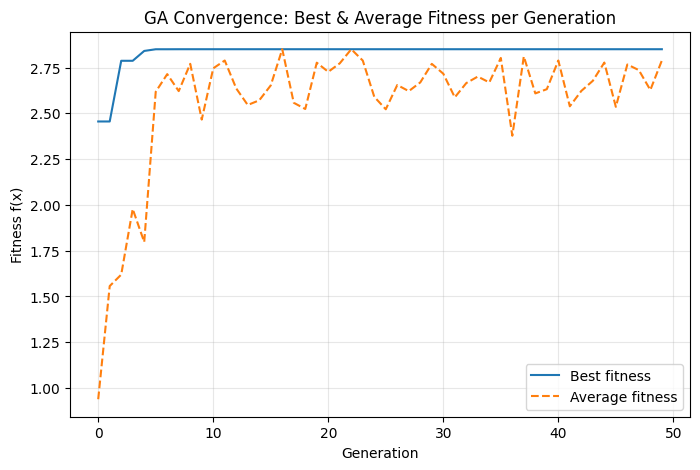

In [10]:
import matplotlib.pyplot as plt

gens = [h[0] for h in history]
best_vals = [h[2] for h in history]
avg_vals = [h[3] for h in history]

plt.figure(figsize=(8, 5))
plt.plot(gens, best_vals, label="Best fitness")
plt.plot(gens, avg_vals, label="Average fitness", linestyle="--")
plt.xlabel("Generation")
plt.ylabel("Fitness f(x)")
plt.title("GA Convergence: Best & Average Fitness per Generation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


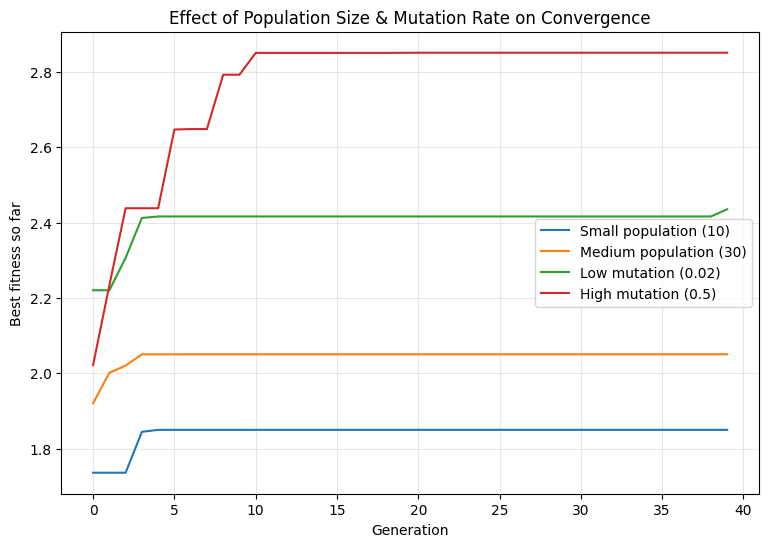

In [11]:
# ----- Effect of parameters on convergence -----
configs = [
    {"pop_size": 10, "generations": 40, "mut_rate": 0.1, "label": "Small population (10)"},
    {"pop_size": 30, "generations": 40, "mut_rate": 0.1, "label": "Medium population (30)"},
    {"pop_size": 30, "generations": 40, "mut_rate": 0.02, "label": "Low mutation (0.02)"},
    {"pop_size": 30, "generations": 40, "mut_rate": 0.5, "label": "High mutation (0.5)"},
]

plt.figure(figsize=(9, 6))
for cfg in configs:
    _, _, hist = genetic_algorithm(pop_size=cfg["pop_size"], generations=cfg["generations"],
                                    mut_rate=cfg["mut_rate"], verbose=False)
    plt.plot([h[0] for h in hist], [h[2] for h in hist], label=cfg["label"])

plt.xlabel("Generation")
plt.ylabel("Best fitness so far")
plt.title("Effect of Population Size & Mutation Rate on Convergence")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Analysis: Effect of GA Parameters on Convergence

- **Population size:** Larger populations explore the search space more broadly and are less likely
  to converge prematurely to a local optimum, but each generation costs more fitness evaluations.
  Small populations converge fast but often get stuck on a local peak of the multi-modal function.
- **Mutation rate:** A very low mutation rate causes the population to lose diversity quickly and
  converge prematurely (fast but often to a sub-optimal peak). A very high mutation rate turns the
  search into something close to random search — it keeps exploring but struggles to *exploit* and
  fine-tune a good solution, so convergence is slow and noisy.
- **Crossover rate:** Higher crossover rates mix genetic material more aggressively, speeding
  exploitation of good regions found by selection, but excessive crossover with no mutation can
  reduce diversity and stagnate the population.
- **Elitism:** Preserving the best individual(s) each generation guarantees fitness never regresses
  and generally speeds up convergence, at a small risk of reducing diversity if elitism count is
  too high.

**Overall:** convergence speed and solution quality depend on balancing *exploration*
(diversity — larger population, higher mutation) against *exploitation* (convergence — selection
pressure, crossover, elitism). The best settings here (moderate population, moderate mutation,
small elitism) reliably find x near the global maximum of f(x) = x·sin(10πx) + 1.
